In [1]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen3:1.7b",
    temperature=0
)

In [2]:
from typing import TypedDict,Annotated,List,Literal
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel,Field
from langgraph.graph import END,StateGraph,START
from typing import List
import operator

#### Orchestrator-Worker Pattern

##### Structured Output

In [3]:
# dish schema for a single dish
class Dish(BaseModel):
    name:str=Field(
        description="Name of the dish (for example, Spaghetti Bolognese, Chicken Curry)"
    )
    ingredients:List[str]=Field(
        description="List of the ingredients needed for this dish, separated by commas"
    )
    location:str=Field(
        description="The cuisine or cultural origin of the dish(for example italy,indian,nepal)"
    )
    

In [4]:
# dish schema for for a list of Dish object
class Dishes(BaseModel):
    sections:List[Dish]=Field(
        description="A list of gorcery sections, one for each dish, with ingedients"
    )

In [5]:
# construct a prompt template
dish_prompt=ChatPromptTemplate.from_messages([(
    "system",
    "you are an assistant that generates a structured grocery list.\n\n"
    "the user wants to prepare the following meals: {meals}\n\n"
    "for each meals, return a section with:\n"
    "- the name of the dish\n"
    "- a comma-separated list of ingredients needed for that dish.\n"
    "- the cusine or cultural origin of the food"
)
    
])

In [6]:
# use LCEL to pipe the prompt to an LLM with a structured output of Dishes
planner_pipe = dish_prompt | llm.with_structured_output(Dishes) # use llm.with_structured_output(Dishes)


In [ ]:
response = planner_pipe.invoke({"meals": "carrot cake"})

In [10]:
from pprint import pprint
pprint(response)

Dishes(sections=[Dish(name='Carrot Cake', ingredients=['1 cup all-purpose flour', '1 cup sugar', '1/2 cup unsalted butter', '1/2 cup milk', '1 egg', '1/2 teaspoon vanilla extract', '1 cup carrots (sliced)', '1/2 cup cake mix (or flour, sugar, and baking powder)'], location='Western (American)')])


#### State(Orchestrations)

In [7]:
class State(TypedDict):
    meals:str
    sections: List[Dish]
    completed_menu: Annotated[List[str],operator.add]
    final_meal_guide:str
    

In [ ]:
dummy_state: State={
    "meals":"Spaghetti Bolognese",
    "sections":[],
    "completed_menu":[],
    "final_meal_guide": ""
    
}
report_sections=planner_pipe.invoke({"meals":dummy_state['meals']})

In [16]:
pprint(report_sections.sections)

[Dish(name='Spaghetti Bolognese', ingredients=['2 cups spaghetti (pasta)', '1 cup chopped onions', '2 cloves garlic', '1 cup chopped celery', '1 cup chopped tomatoes', '1/2 cup olive oil', '1/2 cup beef broth', '1/2 cup beef or pork broth', '1/2 cup chopped parsley', '1/2 cup chopped basil', '1/2 cup grated Parmesan cheese', '1/2 cup flour (or cornstarch for thickening)', '1/2 teaspoon salt', '1/8 teaspoon black pepper', '1/4 cup red wine (optional)'], location='Italian (Bolognese region)')]


In [17]:
for i, section in enumerate(report_sections.sections):
    print(f"Dish {i+1}\n")
    # add each dish to our dummy state
    dummy_state["sections"].append(section)
    print(f"Item Name: {section.name}")
    print(f"Location/Cuisine: {section.location}")
    print(f"Ingredients: {', '.join(section.ingredients)}.")

Dish 1

Item Name: Spaghetti Bolognese
Location/Cuisine: Italian (Bolognese region)
Ingredients: 2 cups spaghetti (pasta), 1 cup chopped onions, 2 cloves garlic, 1 cup chopped celery, 1 cup chopped tomatoes, 1/2 cup olive oil, 1/2 cup beef broth, 1/2 cup beef or pork broth, 1/2 cup chopped parsley, 1/2 cup chopped basil, 1/2 cup grated Parmesan cheese, 1/2 cup flour (or cornstarch for thickening), 1/2 teaspoon salt, 1/8 teaspoon black pepper, 1/4 cup red wine (optional).


##### Orchestrator Node

In [9]:
def orchestrator(state:State):
    """Orhcestrator that generate a structured dish list form the given meals."""
    
    #use the planner_pipe llm to break the user's meal list into structured dish sections
    
    dish_description=planner_pipe.invoke({"meals":state['meals']})
    
    # return the list of dish sections to be passed to worker nodes
    
    return {"sections":dish_description.sections}

##### Worker Node

In [10]:
chef_prompt=ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a world class chef from {location}.\n\n"
        "Please introduce yourself briefly and present a detailed walkthrough for preparing the dish:{name}.\n"
        "Your response should include:\n"
        "- Start with hello with your name and culinary background\n"
        "- A clear list of preparations steps\n"
        "- A full explanations of the cooking process\n\n"
        "Use the following ingredients: {ingredients}"
    )
])

In [11]:
chef_pipe=chef_prompt|llm

In [12]:
class WorkerState(TypedDict):
    section:Dish
    completed_menu:Annotated[list,operator.add]

In [22]:
from langgraph.types import Send

In [23]:
def assign_workers(state:State): #routing functions
    """Assign a worker to each section in the plan"""
    # Kick off section writing in parallel via Send() API
    return [Send("chef_worker",{"section":s}) for s in state['sections']]    

This function acts as a dispatcher: it reads the list of sections from the graph state, creates one Send instruction for each section, and returns all of them so that LangGraph can invoke the chef_worker node once per section, in parallel, with each worker receiving its own isolated state.

```python
#                    assign_workers
#                          |
#        ---------------------------------
#        |               |               |
#        |               |               |
#  Send(Pizza)     Send(Burger)    Send(Pasta)
#        |               |               |
#        v               v               v
#   chef_worker     chef_worker     chef_worker
#        |               |               |
#        ---------------------------------
#                      |
#                Reducer / Merge
#                      |
#                Next graph node
```

In [24]:
def chef_worker(state: WorkerState):
    """Worker node that generates the cooking instructions for one meal section."""

    # Use the language model to generate a meal preparation plan
    # The model receives the dish name, location, and ingredients from the current section
    meal_plan = chef_pipe.invoke({
        "name": state["section"].name,
        "location": state["section"].location,
        "ingredients": state["section"].ingredients
    })

    # Return the generated meal plan wrapped in a list under completed_sections
    # This will be merged into the main state using operator.add in LangGraph
    return {"completed_menu": [meal_plan.content]}


In [26]:
dummy_dishes: List[Dish] = dummy_state["sections"]

# simulate LangGraph's fan-out and merging behavior
for section in dummy_dishes:
    # construct individual WorkerState
    worker_state: WorkerState = {
        "section": section,
        "recipe": []  # LangGraph merges this later
    }

    # call the worker logic directly
    result = chef_worker(worker_state)

    # merge the result into combined menu (LangGraph would do this with operator.add)
    dummy_state["completed_menu"] += result["completed_menu"]

In [29]:
completed_menu_sections = "\n".join(dummy_state["completed_menu"])
print(completed_menu_sections[:1000])

Hello, I’m **Luca**, a Bolognese chef with over 20 years of experience in the region’s culinary traditions. Born in Bologna, I’ve spent my life mastering the art of **spaghetti bolognese**, a dish that embodies the soul of Italian cuisine—simple, hearty, and deeply rooted in history. My recipes are inspired by the rustic, earthy flavors of the Bolognese region, where ingredients like *cannelloni* and *cacio e pepe* are staples.  

---

### **Ingredients**  
- 2 cups spaghetti (pasta)  
- 1 cup chopped onions  
- 2 cloves garlic  
- 1 cup chopped celery  
- 1 cup chopped tomatoes  
- 1/2 cup olive oil  
- 1/2 cup beef or pork broth  
- 1/2 cup beef or pork broth  
- 1/2 cup chopped parsley  
- 1/2 cup chopped basil  
- 1/2 cup grated Parmesan cheese  
- 1/2 cup flour (or cornstarch for thickening)  
- 1/2 teaspoon salt  
- 1/8 teaspoon black pepper  
- 1/4 cup red wine (optional)  

---

### **Step-by-Step Preparation**  

#### **1. Prep the Ingredients**  
- **Sauté the aromatics**: In

In [25]:
def synthesizer(state: State):
    """Synthesize full report from sections"""

    # list of completed sections
    completed_sections = state["completed_menu"]

    # format completed section to str to use as context for final sections
    completed_menu = "\n\n---\n\n".join(completed_sections)

    return {"final_meal_guide": completed_menu}

##### Building the Workflow(Orchestration)

In [26]:
# instantiate the builder
orchestrator_worker_builder=StateGraph(State)

# add the nodes
orchestrator_worker_builder.add_node("orchestrator",orchestrator)
orchestrator_worker_builder.add_node("chef_worker",chef_worker)
orchestrator_worker_builder.add_node("synthesizer",synthesizer)

In [27]:
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator",assign_workers,["chef_worker"]
)
# source node, routing function, list of allowed targets

In [28]:
# add the edges, connections between nodes
orchestrator_worker_builder.add_edge(START,"orchestrator")
orchestrator_worker_builder.add_edge("chef_worker","synthesizer")
orchestrator_worker_builder.add_edge("synthesizer",END)


In [29]:
# compile the builder to get a complete workflow executable
orchestrator_worker = orchestrator_worker_builder.compile()

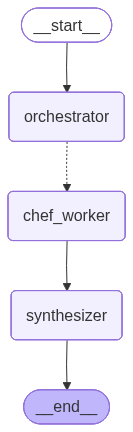

In [30]:
from IPython.display import Image,display
# display the orchestrator workflow using mermaid chart
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [31]:
# invoke the workflow with a string of meals in a dict
state = orchestrator_worker.invoke({"meals": "Steak and eggs"})

In [33]:
# print the first 2000 characters of our final_meal_guide
print(state["final_meal_guide"][:2000])

Hello, I’m Chef Marcus from the United States, a passionate culinary artist with a background in fine dining and a love for crafting bold, flavorful dishes. I’m thrilled to share my recipe for **Steak and Eggs**, a classic that balances richness and simplicity.  

---

### **Ingredients**  
- 1 lb (450g) steak (ribeye, sirloin, or similar)  
- 2 large eggs  
- Salt and pepper  
- 1 tbsp olive oil or butter  
- 1 tsp garlic powder  
- 1 tsp paprika or seasonings (optional)  
- 1 medium onion (sliced)  
- 1 tbsp fresh parsley (or chopped herbs)  
- 1 tsp lemon juice (optional)  
- 1 tsp honey (optional)  

---

### **Preparation Steps**  

#### **1. Marinate the Steak**  
- **Step 1:** Pat the steak dry with paper towels.  
- **Step 2:** In a small bowl, mix **salt, pepper, garlic powder, paprika**, and **olive oil** (or butter).  
- **Step 3:** Submerge the steak in the marinade, ensuring it’s fully coated. Let it rest for 30 minutes (or longer for deeper flavor).  

#### **2. Cook the 